In [1]:
%env TF_USE_LEGACY_KERAS=1

env: TF_USE_LEGACY_KERAS=1


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [4]:
print(tf.__version__)

2.20.0


In [7]:
import tf_keras
print(tf_keras.__version__)

2.20.1


In [44]:
IMG_SIZE = 180
BATCH_SIZE = 32
NUM_CLASSES = 24
EPOCHS_INITIAL = 30
EPOCHS_FINE = 5

In [45]:
train_dir = "data_split/train"
val_dir = "data_split/test"

In [46]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

Found 1133 files belonging to 24 classes.
Found 299 files belonging to 24 classes.


In [47]:
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

In [48]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [14]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [49]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [50]:
base_model.trainable = False 

In [51]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [53]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 6, 6, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization (Batch  (None, 1280)              5120      
 Normalization)                                                  
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 128)               163968    
                                                      

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",      # watch validation loss
    patience=5,              # wait 5 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

In [55]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_INITIAL,
    callbacks=[early_stop]
)

Epoch 1/30
36/36 [==============================] - 43s 772ms/step - loss: 4.1815 - accuracy: 0.0494 - val_loss: 3.0900 - val_accuracy: 0.1070
Epoch 2/30
36/36 [==============================] - 24s 652ms/step - loss: 3.6696 - accuracy: 0.0900 - val_loss: 2.9518 - val_accuracy: 0.1839
Epoch 3/30
36/36 [==============================] - 29s 789ms/step - loss: 3.3279 - accuracy: 0.1236 - val_loss: 2.8115 - val_accuracy: 0.2174
Epoch 4/30
36/36 [==============================] - 35s 953ms/step - loss: 3.0969 - accuracy: 0.1774 - val_loss: 2.6767 - val_accuracy: 0.2542
Epoch 5/30
36/36 [==============================] - 27s 727ms/step - loss: 2.9061 - accuracy: 0.2277 - val_loss: 2.5491 - val_accuracy: 0.3077
Epoch 6/30
36/36 [==============================] - 28s 751ms/step - loss: 2.6649 - accuracy: 0.2515 - val_loss: 2.4337 - val_accuracy: 0.3344
Epoch 7/30
36/36 [==============================] - 20s 539ms/step - loss: 2.5615 - accuracy: 0.2639 - val_loss: 2.3321 - val_accuracy: 0.3445

In [63]:
import numpy as np
import pandas as pd

image_path = "test8.jpg"
img = tf.keras.preprocessing.image.load_img(
        image_path, target_size=(IMG_SIZE, IMG_SIZE)
    )
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

# Get predicted class
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class_index])
print("Confidence:", round(float(confidence)*100, 2), "%")

1/1 [==============================] - 0s 466ms/step
Predicted Class: Melasma
Confidence: 37.48 %


Text(0.5, 1.0, 'Loss')

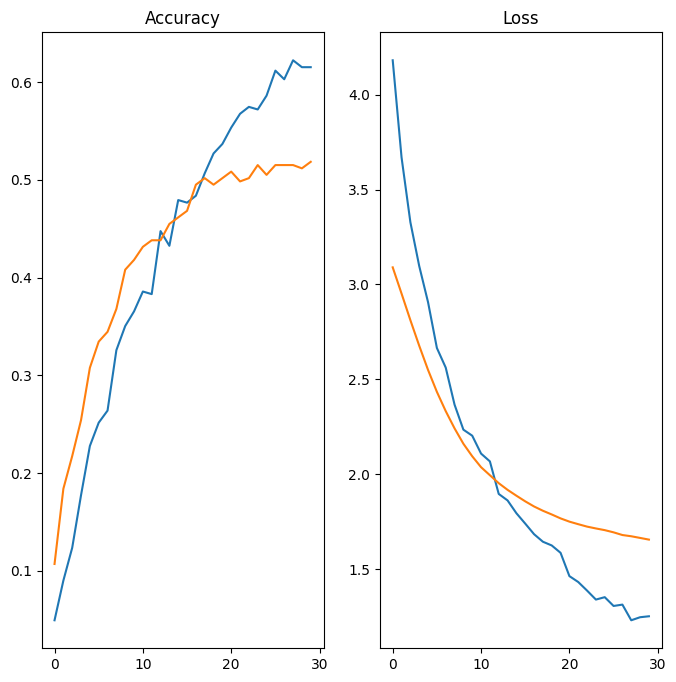

In [57]:
import matplotlib.pyplot as plt
epochs_range = range(30)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [58]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 [==============================] - 0s 363ms/step
                    precision    recall  f1-score   support

              Acne       0.59      0.76      0.67        17
 Actinic Keratosis       0.27      0.25      0.26        16
     Chromhidrosis       0.40      0.29      0.33        14
Eruptive Xanthomas       0.30      0.25      0.27        12
        Erythrasma       0.56      0.45      0.50        11
          Impetigo       0.33      0.20      0.25        10
 Keratosis Pilaris       0.36      0.56      0.44        16
           Leprosy       0.62      0.73      0.67        11
             Lupus       0.44      0.36      0.40        11
      Lyme Disease       0.80      0.73      0.76        11
           Measles       0.58      0.58      0.58        12
          Melanoma       0.82      0.93      0.88        15
           Melasma       0.67      0.77      0.71        13
          Otophyma       0.57      0.57      0.57         7
          RingWorm       0.60      0.55      0

In [64]:
model.save("Image_classify_v5.keras")

In [40]:
base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)

Epoch 1/5
36/36 [==============================] - 44s 857ms/step - loss: 1.7317 - accuracy: 0.5313 - val_loss: 1.9802 - val_accuracy: 0.4381
Epoch 2/5
36/36 [==============================] - 22s 595ms/step - loss: 1.7469 - accuracy: 0.5216 - val_loss: 1.9764 - val_accuracy: 0.4348
Epoch 3/5
36/36 [==============================] - 22s 601ms/step - loss: 1.7227 - accuracy: 0.5199 - val_loss: 1.9726 - val_accuracy: 0.4348
Epoch 4/5
36/36 [==============================] - 23s 617ms/step - loss: 1.7331 - accuracy: 0.5225 - val_loss: 1.9690 - val_accuracy: 0.4348
Epoch 5/5
36/36 [==============================] - 26s 715ms/step - loss: 1.7438 - accuracy: 0.5207 - val_loss: 1.9655 - val_accuracy: 0.4348
